🔬 Analyzing text: "The task of text classification (TC), also known as text categorization, is a foundational problem in Natural Language Processing (NLP) with wide-ranging applications, from sentiment analysis and topic labeling to spam detection.At its core, text classification is a supervised learning task wherein a model is trained to map a piece of text to one or more predefined labels or classes.The evolution of models designed for this task charts a course through the major paradigms of machine learning, from early statistical methods to the sophisticated deep learning architectures that dominate the field today.This journey is characterized by increasingly powerful methods of text representation and a progressive ability to capture the complex, contextual nature of human language."
--------------------------------------------------
✅ Graph construction complete.

Nodes (with attributes):
  - Node 0: {'label': 'The task of text classification ( TC ) , also known as text categori

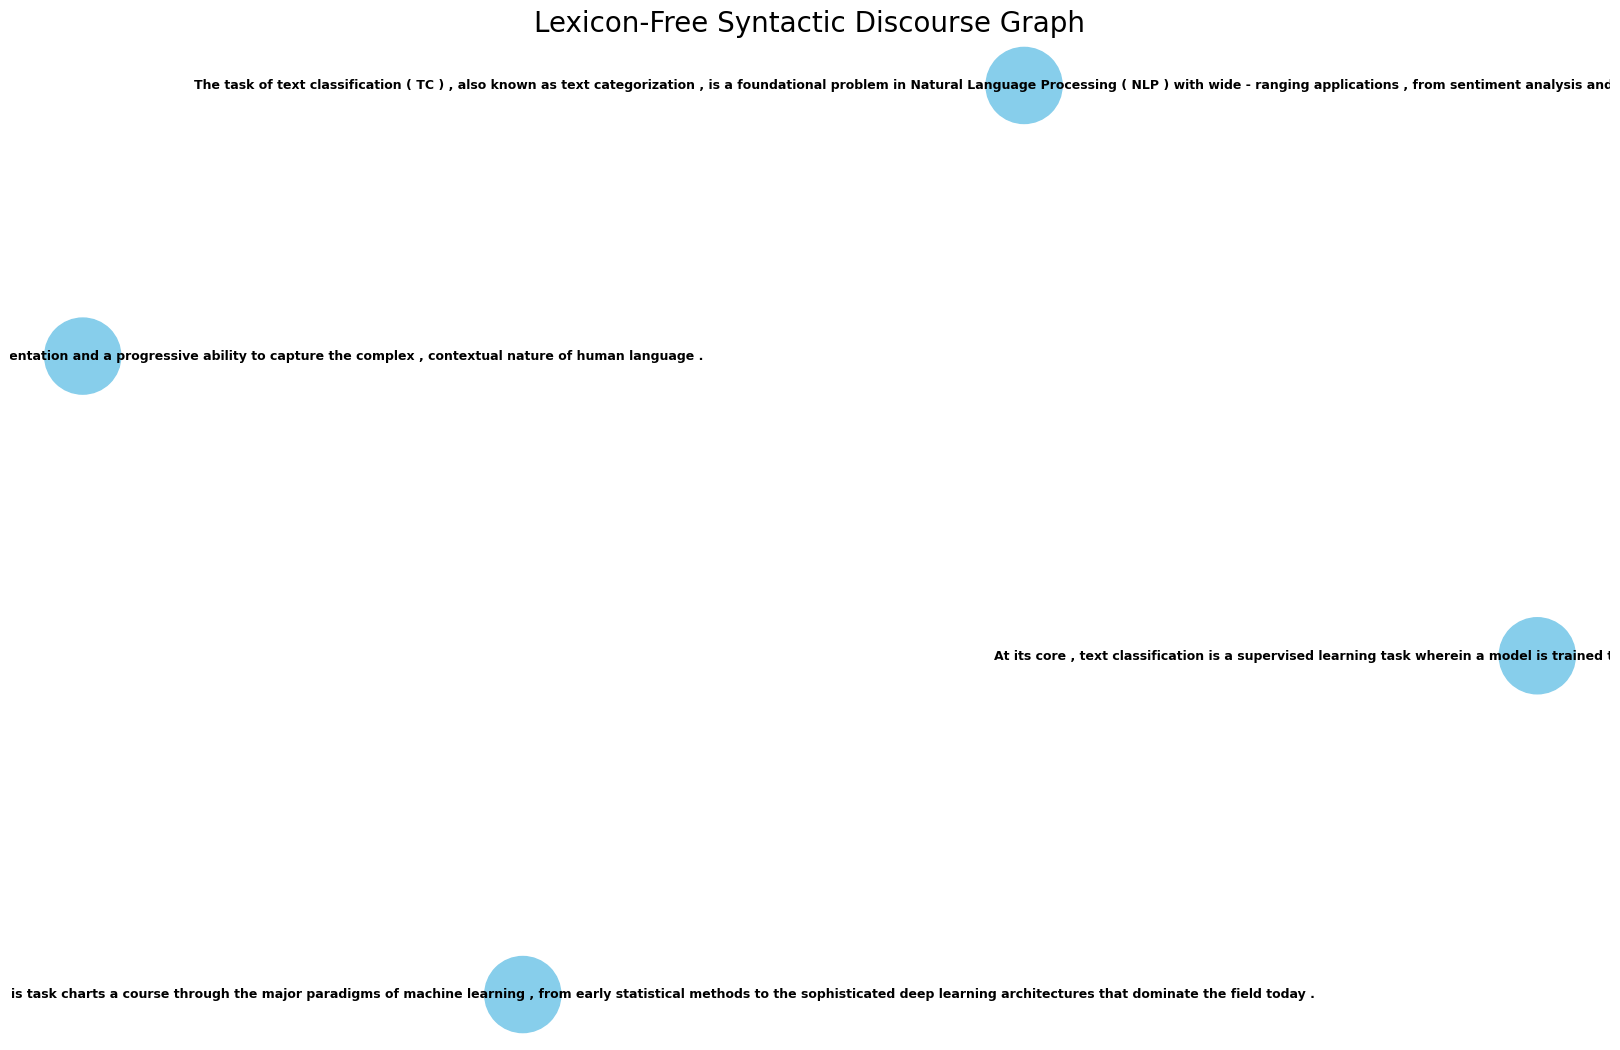

In [1]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt

class SyntacticGraphBuilder:
    """
    Constructs an explainable discourse graph from text using syntactic roles.

    This lexicon-free version dynamically identifies discourse connectives by
    analyzing the grammatical function of words (their dependency labels). It
    targets words acting as coordinating conjunctions ('cc'), markers for
    subordinate clauses ('mark'), and clause-level adverbial modifiers ('advmod').

    This approach is more flexible than a fixed lexicon but replaces semantic
    categories (e.g., 'Contrast') with syntactic ones (e.g., 'cc').
    """

    def __init__(self, model="en_core_web_lg"):
        """Initializes the builder with a spaCy NLP model."""
        self.nlp = spacy.load(model)
        # Target dependency labels that indicate discourse relations.
        self.CONNECTIVE_DEPS = {'cc', 'mark', 'advmod'}

    def _get_clause_text(self, root_token):
        """Extracts the full text of a clause from its root token's subtree."""
        sorted_tokens = sorted(root_token.subtree, key=lambda t: t.i)
        return " ".join([token.text for token in sorted_tokens])

    def _create_clause_nodes(self, doc, G):
        """PASS 1: Find all main clauses and create a node for each."""
        root_i_to_node_id = {}
        node_counter = 0
        for sent in doc.sents:
            if sent.root.i not in root_i_to_node_id:
                node_id = node_counter
                root_i_to_node_id[sent.root.i] = node_id
                clause_text = self._get_clause_text(sent.root)
                G.add_node(node_id, label=clause_text, type='phrase', root_i=sent.root.i)
                node_counter += 1
        return root_i_to_node_id, node_counter

    def _create_mediator_edges(self, doc, G, root_i_to_node_id, node_counter):
        """PASS 2: Find syntactic connectives and create mediator nodes and edges."""
        prev_sent_root = None
        for sent in doc.sents:
            for token in sent:
                if token.dep_ not in self.CONNECTIVE_DEPS:
                    continue

                # --- Filtering Heuristics to reduce noise ---
                # A 'cc' must actually connect clauses (i.e., its head has a conjunct child).
                if token.dep_ == 'cc' and not any(child.dep_ == 'conj' for child in token.head.children):
                    continue
                # An 'advmod' should be a sentence-level connective, not a manner adverb.
                if token.dep_ == 'advmod' and not (token.is_sent_start or token.head == sent.root):
                    continue

                # --- Syntactic Logic to find connected phrases ---
                phrase_a_root, phrase_b_root = None, None
                conn_root = token

                if conn_root.dep_ == 'cc':
                    phrase_a_root = conn_root.head
                    phrase_b_root = next((child for child in phrase_a_root.children if child.dep_ == 'conj'), None)
                elif conn_root.dep_ in ('mark', 'advmod'):
                    phrase_b_root = conn_root.head
                    if conn_root.is_sent_start and prev_sent_root:
                        phrase_a_root = prev_sent_root
                    else:
                        phrase_a_root = conn_root.head.head

                if not phrase_a_root or not phrase_b_root:
                    continue

                node_id_a = root_i_to_node_id.get(phrase_a_root.i)
                node_id_b = root_i_to_node_id.get(phrase_b_root.i)

                if node_id_a is None or node_id_b is None:
                    continue

                # Create the mediator node
                mediator_id = node_counter
                G.add_node(mediator_id, label=f'"{conn_root.text}"', type='mediator', category=conn_root.dep_)
                node_counter += 1

                G.add_edge(mediator_id, node_id_a, relation='refers_to')
                G.add_edge(mediator_id, node_id_b, relation='governs')

            prev_sent_root = sent.root

    def build_graph(self, text: str) -> nx.DiGraph:
        """Orchestrates the two-pass graph construction."""
        doc = self.nlp(text)
        G = nx.DiGraph()
        root_i_to_node_id, node_counter = self._create_clause_nodes(doc, G)
        self._create_mediator_edges(doc, G, root_i_to_node_id, node_counter)
        return G

    def visualize_graph(self, G: nx.DiGraph):
        """Creates and displays a visualization of the graph."""
        if not G.nodes:
            print("Graph is empty. Nothing to visualize.")
            return

        pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
        node_labels = nx.get_node_attributes(G, 'label')
        node_types = nx.get_node_attributes(G, 'type')
        node_colors = ['salmon' if node_types.get(n) == 'mediator' else 'skyblue' for n in G.nodes()]

        plt.figure(figsize=(16, 10))
        nx.draw(G, pos, labels=node_labels, with_labels=True, node_color=node_colors,
                node_size=3000, font_size=9, font_weight='bold', arrowsize=20)
        edge_labels = nx.get_edge_attributes(G, 'relation')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
        plt.title("Lexicon-Free Syntactic Discourse Graph", fontsize=20)
        plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":
    sample_text = (
        "The task of text classification (TC), also known as text categorization, is a foundational problem in Natural Language Processing (NLP) with wide-ranging applications, from sentiment analysis and topic labeling to spam detection."
        "At its core, text classification is a supervised learning task wherein a model is trained to map a piece of text to one or more predefined labels or classes."
        "The evolution of models designed for this task charts a course through the major paradigms of machine learning, from early statistical methods to the sophisticated deep learning architectures that dominate the field today."
        "This journey is characterized by increasingly powerful methods of text representation and a progressive ability to capture the complex, contextual nature of human language."
    )

    print(f"🔬 Analyzing text: \"{sample_text}\"")
    print("-" * 50)

    builder = SyntacticGraphBuilder()
    discourse_graph = builder.build_graph(sample_text)

    print("✅ Graph construction complete.\n")
    print("Nodes (with attributes):")
    for node, data in discourse_graph.nodes(data=True):
        print(f"  - Node {node}: {data}")

    print("\nEdges (representing mediated relationships):")
    if not discourse_graph.edges:
        print("  - No discourse relationships were identified.")
    else:
        for u, v, data in discourse_graph.edges(data=True):
            u_label = discourse_graph.nodes[u]['label']
            v_label = discourse_graph.nodes[v]['label']
            print(f"  - ({u_label}) --[{data['relation']}]--> ({v_label})")

    builder.visualize_graph(discourse_graph)